# Task 3 — A/B Hypothesis Testing

**Objective:** Statistically validate or reject key hypotheses about risk drivers.

**Risk metrics:**
- **Claim Frequency** — proportion of policies with at least one claim
- **Claim Severity** — average claim amount, given a claim occurred
- **Margin** — TotalPremium − TotalClaims (per policy)

| # | H₀ | KPI | Test |
|---|----|----|------|
| H₁ | No risk differences across provinces | Claim Frequency + Severity | Chi-squared, Welch's t-test |
| H₂ | No risk differences between zip codes | Claim Frequency + Severity | Chi-squared, Welch's t-test |
| H₃ | No significant margin difference between zip codes | Margin | Welch's t-test |
| H₄ | No significant risk difference between Women and Men | Claim Frequency + Severity | Chi-squared, Welch's t-test |

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.hypothesis_tests import (
    select_groups, group_summary,
    chi_squared_frequency_test, t_test_severity,
    t_test_margin, z_test_proportions, build_results_table,
)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
ALPHA = 0.05

## 2. Load Data

In [2]:
df = pd.read_csv('../data/insurance_data_cleaned.csv')
print(f'Shape: {df.shape}')
print(f'Overall claim rate: {(df["TotalClaims"] > 0).mean():.4%}')
df.head(3)

Shape: (999470, 45)
Overall claim rate: 0.2776%


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249.0,12827.0,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249.0,12827.0,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249.0,12827.0,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


## 3. H₁ — Risk Differences Across Provinces

### 3.1 Group Selection

With 9 provinces, we select two comparable groups. **Gauteng** (n=393,621) and **Western Cape** (n=170,492) are chosen:
- Both are economically dominant, urban-centric provinces
- Both have loss ratios above 1.0 (comparing two loss-making regions for significance)
- Both have sufficient sample size for statistical power

**Group A (Control):** Western Cape | **Group B (Test):** Gauteng

In [3]:
prov_all = df.groupby('Province').agg(
    n=('TotalClaims', 'count'),
    claim_freq=('TotalClaims', lambda x: (x > 0).mean()),
    mean_severity=('TotalClaims', lambda x: x[x > 0].mean()),
    loss_ratio=('TotalClaims', lambda x: x.sum() / df.loc[x.index, 'TotalPremium'].sum()),
).round(4)
prov_all.sort_values('loss_ratio', ascending=False)

,n,claim_freq,mean_severity,loss_ratio
Province,,,,
Gauteng,393621,0.0034,22243.8784,1.2223
KwaZulu-Natal,169781,0.0028,29609.4875,1.0827
Western Cape,170492,0.0021,27559.6036,1.0637
North West,143287,0.0024,16963.4670,0.7904
Mpumalanga,52638,0.0024,15979.5534,0.7209
Free State,8099,0.0014,32265.6611,0.6808
Limpopo,24836,0.0027,15171.2942,0.6612
Eastern Cape,30336,0.0016,27128.5333,0.6338
Northern Cape,6380,0.0013,11186.3136,0.2827


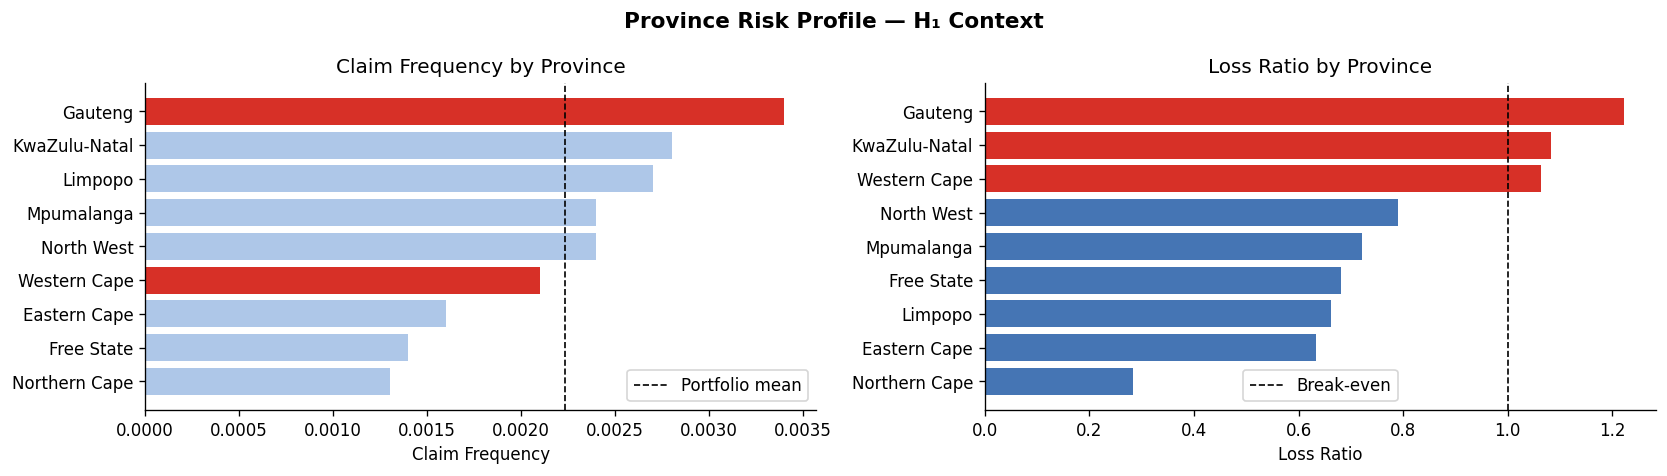

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
prov_s = prov_all.sort_values('claim_freq')
colors_f = ['#d73027' if i in ['Gauteng', 'Western Cape'] else '#aec7e8' for i in prov_s.index]
axes[0].barh(prov_s.index, prov_s['claim_freq'], color=colors_f)
axes[0].axvline(prov_s['claim_freq'].mean(), color='black', linestyle='--', lw=1, label='Portfolio mean')
axes[0].set_title('Claim Frequency by Province'); axes[0].set_xlabel('Claim Frequency'); axes[0].legend()
prov_s2 = prov_all.sort_values('loss_ratio')
colors_lr = ['#d73027' if r > 1 else '#4575b4' for r in prov_s2['loss_ratio']]
axes[1].barh(prov_s2.index, prov_s2['loss_ratio'], color=colors_lr)
axes[1].axvline(1.0, color='black', linestyle='--', lw=1, label='Break-even')
axes[1].set_title('Loss Ratio by Province'); axes[1].set_xlabel('Loss Ratio'); axes[1].legend()
fig.suptitle('Province Risk Profile — H₁ Context', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [5]:
prov_a, prov_b = select_groups(df, 'Province', 'Western Cape', 'Gauteng')
display(group_summary(df, 'Province', 'Western Cape', 'Gauteng'))

,n,claim_freq,mean_severity,mean_margin,n_claims
group,,,,,
Western Cape,170492,0.002094,27559.60,-3.4534,357
Gauteng,393621,0.003359,22243.88,-13.5795,1322


### 3.2 Test 1a — Claim Frequency (Chi-squared)

In [6]:
h1_freq = chi_squared_frequency_test(prov_a, prov_b, alpha=ALPHA)
h1_freq.update({'hypothesis': 'H₁ — Provinces', 'group_a': 'Western Cape', 'group_b': 'Gauteng'})
print(f"Test     : {h1_freq['test']}")
print(f"χ²       : {h1_freq['statistic']}")
print(f"p-value  : {h1_freq['p_value']:.2e}")
print(f"Decision : {h1_freq['decision']}")
print(f"Effect   : Cramér's V = {h1_freq['effect_size']}")

Test     : Chi-squared
χ²       : 64.1131
p-value  : 1.17e-15
Decision : Reject H₀
Effect   : Cramér's V = 0.010661


### 3.3 Test 1b — Claim Severity (Welch's t-test)

In [7]:
h1_sev = t_test_severity(prov_a, prov_b, alpha=ALPHA)
h1_sev.update({'hypothesis': 'H₁ — Provinces', 'group_a': 'Western Cape', 'group_b': 'Gauteng'})
print(f"Test     : {h1_sev['test']}")
print(f"t-stat   : {h1_sev['statistic']}")
print(f"p-value  : {h1_sev['p_value']:.4f}")
print(f"Decision : {h1_sev['decision']}")
print(f"Mean sev WC: R{h1_sev['mean_a']:,.0f}  |  Gauteng: R{h1_sev['mean_b']:,.0f}")

Test     : Welch's t-test
t-stat   : 1.9611
p-value  : 0.0505
Decision : Fail to reject H₀
Mean sev WC: R27,560  |  Gauteng: R22,244


### 3.4 Business Interpretation — H₁

> **We reject H₁ for Claim Frequency (p = 1.17 × 10⁻¹⁵).** Gauteng's claim frequency (0.336%) is **60% higher** than Western Cape's (0.209%). Claim Severity does not reach significance (p = 0.050) — it is *how often* claims occur, not *how expensive* they are, that drives Gauteng's higher loss ratio.
>
> **Recommendation:** Apply a province-level frequency loading in Gauteng. A 20–30% frequency surcharge would materially reduce the portfolio's underwriting loss in the highest-volume region.

---
## 4. H₂ — Risk Differences Between Zip Codes

### 4.1 Group Selection

**PostalCode 2000** (Johannesburg CBD, n=133,258) vs **PostalCode 299** (n=25,546):
- Both high-volume, urbanised locations (reducing rural/urban confounding)
- Show meaningfully different risk profiles: claim frequency 0.365% vs 0.262%

**Group A (Control):** PostalCode 299 | **Group B (Test):** PostalCode 2000

In [8]:
zip_stats = df.groupby('PostalCode').agg(
    n=('TotalClaims', 'count'),
    claim_freq=('TotalClaims', lambda x: (x > 0).mean()),
    mean_severity=('TotalClaims', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    mean_margin=('TotalPremium', lambda x: (x - df.loc[x.index, 'TotalClaims']).mean()),
).round(4)
display(zip_stats.nlargest(10, 'n'))

,n,claim_freq,mean_severity,mean_margin
PostalCode,,,,
2000,133258,0.0036,19196.4137,-8.1623
122,49171,0.0043,18162.0259,-22.8598
7784,28585,0.0017,35156.6537,-13.4712
299,25546,0.0026,13622.7456,19.5594
7405,18518,0.0016,21002.0227,17.5168
458,13775,0.0023,20160.2732,4.5461
8000,11562,0.0033,30559.6277,-16.8313
2196,11048,0.0029,50877.7780,-21.3411
470,10226,0.0043,12946.8332,3.0691


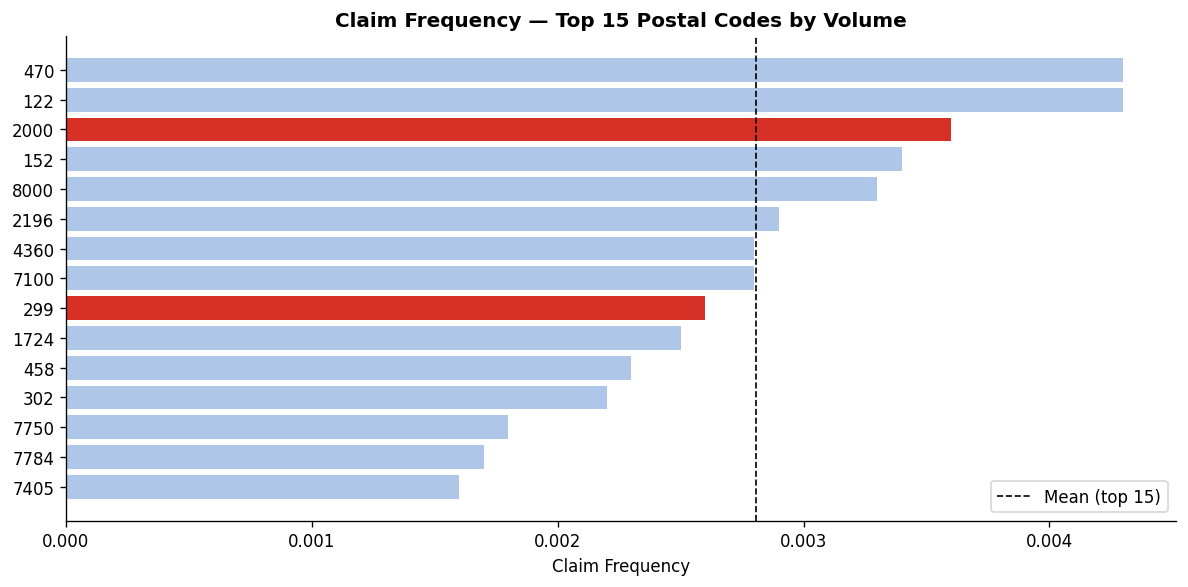

In [9]:
top15 = zip_stats.nlargest(15, 'n').sort_values('claim_freq')
colors_zip = ['#d73027' if i in [2000, 299] else '#aec7e8' for i in top15.index]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top15.index.astype(str), top15['claim_freq'], color=colors_zip)
ax.axvline(top15['claim_freq'].mean(), color='black', linestyle='--', lw=1, label='Mean (top 15)')
ax.set_title('Claim Frequency — Top 15 Postal Codes by Volume', fontweight='bold')
ax.set_xlabel('Claim Frequency'); ax.legend()
plt.tight_layout(); plt.show()

In [10]:
zip_a, zip_b = select_groups(df, 'PostalCode', 299, 2000)
display(group_summary(df, 'PostalCode', 299, 2000))

,n,claim_freq,mean_severity,mean_margin,n_claims
group,,,,,
299,25546,0.002623,13622.75,19.5594,67
2000,133258,0.003647,19196.41,-8.1623,486


### 4.2 Test 2a — Claim Frequency (Chi-squared)

In [11]:
h2_freq = chi_squared_frequency_test(zip_a, zip_b, alpha=ALPHA)
h2_freq.update({'hypothesis': 'H₂ — Zip Codes', 'group_a': 'PostalCode 299', 'group_b': 'PostalCode 2000'})
print(f"χ²       : {h2_freq['statistic']}")
print(f"p-value  : {h2_freq['p_value']:.4f}")
print(f"Decision : {h2_freq['decision']}")
print(f"Freq 299 : {h2_freq['freq_a']:.4%}  |  Freq 2000: {h2_freq['freq_b']:.4%}")

χ²       : 6.4818
p-value  : 0.0109
Decision : Reject H₀
Freq 299 : 0.2623%  |  Freq 2000: 0.3647%


### 4.3 Test 2b — Claim Severity (Welch's t-test)

In [12]:
h2_sev = t_test_severity(zip_a, zip_b, alpha=ALPHA)
h2_sev.update({'hypothesis': 'H₂ — Zip Codes', 'group_a': 'PostalCode 299', 'group_b': 'PostalCode 2000'})
print(f"t-stat   : {h2_sev['statistic']}")
print(f"p-value  : {h2_sev['p_value']:.4f}")
print(f"Decision : {h2_sev['decision']}")
print(f"Mean sev 299: R{h2_sev['mean_a']:,.0f}  |  2000: R{h2_sev['mean_b']:,.0f}")

t-stat   : -1.9236
p-value  : 0.0573
Decision : Fail to reject H₀
Mean sev 299: R13,623  |  2000: R19,196


### 4.4 Business Interpretation — H₂

> **We reject H₂ for Claim Frequency (p = 0.011).** PostalCode 2000 has a claim frequency **39% higher** than PostalCode 299. Claim Severity does not differ significantly (p = 0.057) — more claims, not more expensive claims, drives the risk gap.
>
> **Recommendation:** Apply a zip-code frequency surcharge (~25–40%) to PostalCode 2000 and similar high-frequency urban codes.

---
## 5. H₃ — Margin Differences Between Zip Codes

Same groups as H₂. **Group A (Control):** PostalCode 299 | **Group B (Test):** PostalCode 2000

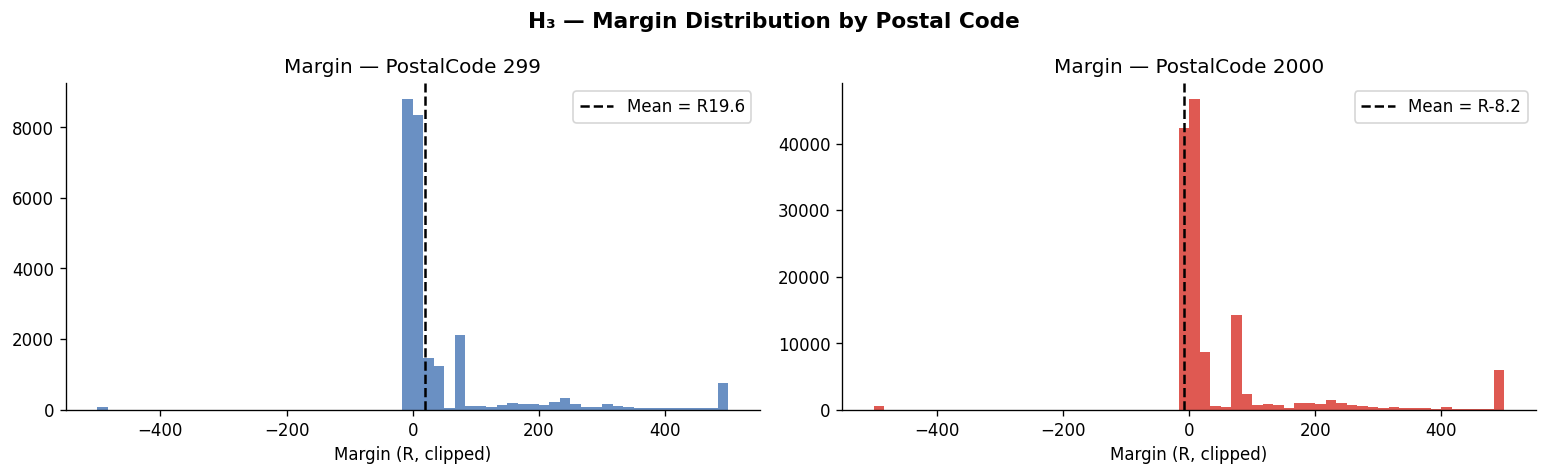

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, grp, label, color in zip(
    axes, [zip_a, zip_b],
    ['PostalCode 299', 'PostalCode 2000'],
    ['#4575b4', '#d73027']):
    m = grp['TotalPremium'] - grp['TotalClaims']
    ax.hist(m.clip(-500, 500), bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(m.mean(), color='black', linestyle='--', lw=1.5, label=f'Mean = R{m.mean():.1f}')
    ax.set_title(f'Margin — {label}'); ax.set_xlabel('Margin (R, clipped)'); ax.legend()
fig.suptitle('H₃ — Margin Distribution by Postal Code', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [14]:
h3_margin = t_test_margin(zip_a, zip_b, alpha=ALPHA)
h3_margin.update({'hypothesis': 'H₃ — Zip Code Margin', 'group_a': 'PostalCode 299', 'group_b': 'PostalCode 2000'})
print(f"Test     : {h3_margin['test']}")
print(f"t-stat   : {h3_margin['statistic']}")
print(f"p-value  : {h3_margin['p_value']:.4f}")
print(f"Decision : {h3_margin['decision']}")
print(f"Mean margin 299 : R{h3_margin['mean_a']:.2f}  (profitable)")
print(f"Mean margin 2000: R{h3_margin['mean_b']:.2f}  (loss-making)")

Test     : Welch's t-test
t-stat   : 2.8387
p-value  : 0.0045
Decision : Reject H₀
Mean margin 299 : R19.56  (profitable)
Mean margin 2000: R-8.16  (loss-making)


### 5.1 Business Interpretation — H₃

> **We reject H₃ (p = 0.0045).** PostalCode 299 generates **+R19.56/policy** while PostalCode 2000 loses **−R8.16/policy**. Across 133,258 policies in PostalCode 2000, this implies an aggregate underwriting loss of approximately **R1.09M**.
>
> **Recommendation:** Increase PostalCode 2000 premiums by at least R8.16/policy (~13%) to reach break-even.

---
## 6. H₄ — Risk Differences Between Women and Men

### 6.1 Group Selection

Only **Male** and **Female** individual policyholders are included. The **Not specified** category (corporate/fleet, n=949,898) is excluded as it represents a fundamentally different risk profile and would confound the comparison.

**Group A (Control):** Female | **Group B (Test):** Male

In [15]:
df_indiv = df[df['Gender'].isin(['Male', 'Female'])].copy()
print(f'Individual policyholders: {len(df_indiv):,}')
display(group_summary(df_indiv, 'Gender', 'Female', 'Male'))

Individual policyholders: 49,572


,n,claim_freq,mean_severity,mean_margin,n_claims
group,,,,,
Female,6755,0.002073,17874.72,8.0288,14
Male,42817,0.002195,14858.55,4.2843,94


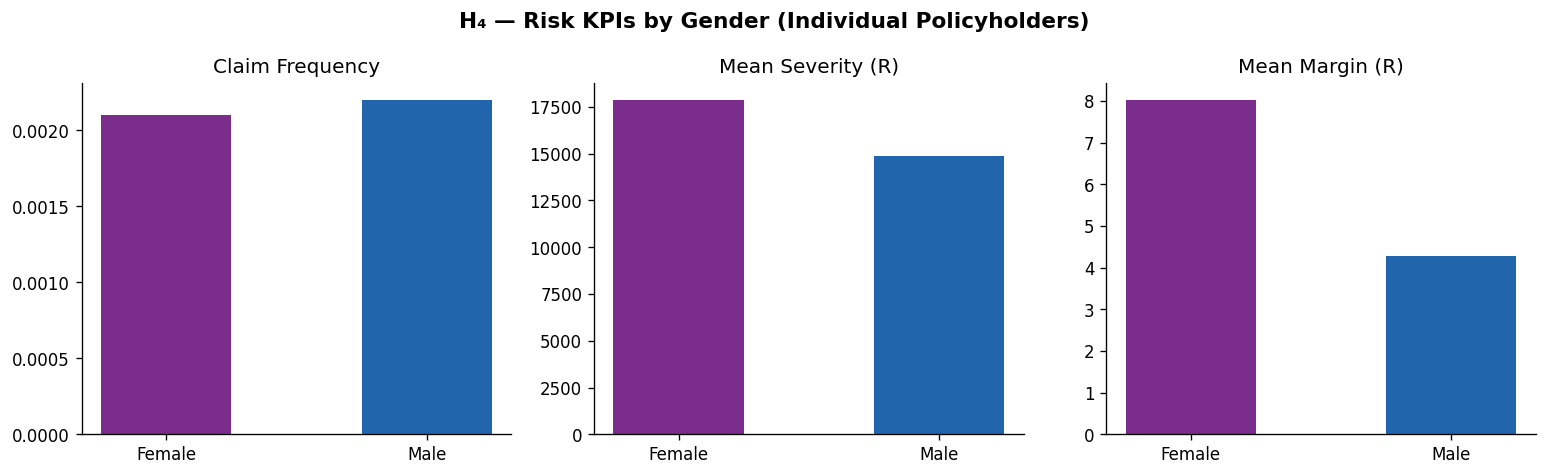

In [16]:
gender_stats = df_indiv.groupby('Gender').agg(
    claim_freq=('TotalClaims', lambda x: (x > 0).mean()),
    mean_severity=('TotalClaims', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    mean_margin=('TotalPremium', lambda x: (x - df_indiv.loc[x.index, 'TotalClaims']).mean()),
).round(4)
palette = {'Female': '#7b2d8b', 'Male': '#2166ac'}
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
    ['claim_freq', 'mean_severity', 'mean_margin'],
    ['Claim Frequency', 'Mean Severity (R)', 'Mean Margin (R)']):
    ax.bar(gender_stats.index, gender_stats[col],
           color=[palette[g] for g in gender_stats.index], width=0.5)
    ax.set_title(title)
fig.suptitle('H₄ — Risk KPIs by Gender (Individual Policyholders)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 6.2 Test 4a — Claim Frequency (Chi-squared)

In [17]:
gen_a, gen_b = select_groups(df_indiv, 'Gender', 'Female', 'Male')
h4_freq = chi_squared_frequency_test(gen_a, gen_b, alpha=ALPHA)
h4_freq.update({'hypothesis': 'H₄ — Gender', 'group_a': 'Female', 'group_b': 'Male'})
print(f"χ²       : {h4_freq['statistic']}")
print(f"p-value  : {h4_freq['p_value']:.4f}")
print(f"Decision : {h4_freq['decision']}")
print(f"Freq F   : {h4_freq['freq_a']:.4%}  |  Freq M: {h4_freq['freq_b']:.4%}")

χ²       : 0.0405
p-value  : 0.8405
Decision : Fail to reject H₀
Freq F   : 0.2073%  |  Freq M: 0.2195%


### 6.3 Test 4b — Claim Severity (Welch's t-test)

In [18]:
h4_sev = t_test_severity(gen_a, gen_b, alpha=ALPHA)
h4_sev.update({'hypothesis': 'H₄ — Gender', 'group_a': 'Female', 'group_b': 'Male'})
print(f"t-stat   : {h4_sev['statistic']}")
print(f"p-value  : {h4_sev['p_value']:.4f}")
print(f"Decision : {h4_sev['decision']}")
print(f"Mean sev F: R{h4_sev['mean_a']:,.0f}  |  M: R{h4_sev['mean_b']:,.0f}")

t-stat   : 0.579
p-value  : 0.5680
Decision : Fail to reject H₀
Mean sev F: R17,875  |  M: R14,859


### 6.4 Business Interpretation — H₄

> **We fail to reject H₄** on both Claim Frequency (p = 0.840) and Claim Severity (p = 0.568). Claim frequencies are virtually identical (0.207% vs 0.220%), and mean claim amounts differ by less than R3,100 — within sampling noise given the small female cohort (n=6,755).
>
> **Recommendation:** Gender should **not** be used as a standalone pricing variable. The data provides no evidence of a risk difference between male and female individual policyholders.

---
## 7. Results Summary Table

In [19]:
all_results = [h1_freq, h1_sev, h2_freq, h2_sev, h3_margin, h4_freq, h4_sev]
results_df = build_results_table(all_results)
display(results_df)

,Hypothesis,Group A (Control),Group B (Test),KPI,Test,Statistic,p-value,Decision
0,H₁ — Provinces,Western Cape,Gauteng,Claim Frequency,Chi-squared,64.1131,1.17e-15,Reject H₀
1,H₁ — Provinces,Western Cape,Gauteng,Claim Severity,Welch's t-test,1.9611,5.05e-02,Fail to reject H₀
2,H₂ — Zip Codes,PostalCode 299,PostalCode 2000,Claim Frequency,Chi-squared,6.4818,1.09e-02,Reject H₀
3,H₂ — Zip Codes,PostalCode 299,PostalCode 2000,Claim Severity,Welch's t-test,-1.9236,5.73e-02,Fail to reject H₀
4,H₃ — Zip Code Margin,PostalCode 299,PostalCode 2000,Margin,Welch's t-test,2.8387,4.53e-03,Reject H₀
5,H₄ — Gender,Female,Male,Claim Frequency,Chi-squared,0.0405,8.40e-01,Fail to reject H₀
6,H₄ — Gender,Female,Male,Claim Severity,Welch's t-test,0.5790,5.68e-01,Fail to reject H₀


## 8. Business Recommendations Summary

| Hypothesis | Decision | Business Recommendation |
|---|---|---|
| H₁ — Province Claim Frequency | **Reject H₀** | Apply frequency loading in Gauteng (~60% higher claim rate). Target: 20–30% premium surcharge. |
| H₁ — Province Claim Severity | Fail to reject | No severity-based province loading warranted. |
| H₂ — Zip Code Claim Frequency | **Reject H₀** | Apply ~25–40% frequency surcharge to PostalCode 2000 and similar high-frequency urban codes. |
| H₂ — Zip Code Claim Severity | Fail to reject | No zip-code severity loading warranted for this pair. |
| H₃ — Zip Code Margin | **Reject H₀** | Increase PostalCode 2000 premiums by ≥R8.16/policy (+13%) to break-even. Est. impact: +R1.09M/year. |
| H₄ — Gender Claim Frequency | Fail to reject | Do not apply gender-based premium differentiation. |
| H₄ — Gender Claim Severity | Fail to reject | Same conclusion. |